# SIT307 – Machine Learning

## 8.1 Distinction Task – Classification Models

### Machine Learning Mini Project: Regression Analysis of Sydney Property Sales

**Student Name:** Anshika  

**Unit:** SIT307 – Machine Learning  

**Task:** 8.1D – Machine Learning Mini Project

**Dataset:** Housing in Sydney

# Part 0: Setup and Initial Inspection

This section loads the required Python libraries and the housing dataset, then performs an initial inspection of its structure, dimensions, data types, missing values, duplicate records, and summary statistics.

In [3]:
# Data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
price_formatter = FuncFormatter(
    lambda x, pos: f'${x / 1_000_000:.1f}M'
)

import seaborn as sns

sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="Set2"
)

plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

# Data splitting
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    PolynomialFeatures,
    StandardScaler
)

# Pipelines and models
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# Model evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Model interpretation
from sklearn.inspection import permutation_importance

import joblib

In [4]:
df = pd.read_csv("Housing.csv")

df.head()

,Address,Suburb,Postcode,SalePrice,SaleDate,PropertyType,Bedrooms,Bathrooms,ParkingSpaces,Area_m2
0,"8/88 Avenue Road, Mosman NSW 2088",Mosman,2088.0,"730,000",8-Sep-26,Apartment,1.0,1.0,1.0,NaN
1,"7/10 Muston Street, Mosman NSW 2088",Mosman,2088.0,"750,000",3-Sep-26,Apartment,1.0,1.0,0.0,45
2,"13/5 The Esplanade, Mosman NSW 2088",Mosman,2088.0,"$1,450,000",14-Sep-26,Apartment,1.0,1.0,0.0,45
3,"3/17 Milner Street, Mosman",Mosman,2088.0,"$790,000",21-Aug-26,Apartment,1.0,1.0,0.0,45
4,"111/116 Belmont Road, Mosman",Mosman,2088.0,"$930,000",19-Aug-26,Apartment,1.0,1.0,1.0,74


## Dataset Information

The dataset, `Housing.csv`, contains residential property sales collected from three Sydney suburbs:

- **Mosman (2088)**

- **Marrickville (2204)**

- **Blacktown (2148)**

These suburbs were selected to represent different segments of the Sydney housing market, ranging from higher-priced properties in Mosman to more moderately priced properties in Marrickville and Blacktown.

The raw dataset contains **108 rows and 10 variables**. During data cleaning, one completely empty row and one retirement-living property were removed, leaving **106 residential properties** for analysis and modelling.

The dataset contains the following variables:

| Variable | Description |
|---|---|
| `Address` | Property address |
| `Suburb` | Suburb where the property is located |
| `Postcode` | Property postcode |
| `SalePrice` | Recorded property sale price in AUD |
| `SaleDate` | Date on which the property was sold |
| `PropertyType` | House, apartment or townhouse |
| `Bedrooms` | Number of bedrooms |
| `Bathrooms` | Number of bathrooms |
| `ParkingSpaces` | Number of available parking spaces |
| `Area_m2` | Property area measured in square metres |

For houses, `Area_m2` generally represents **land size**, while for apartments and units it represents the available **floor or unit area**. Missing area values are handled during the preprocessing stage.

In [6]:
print("Dataset shape:", df.shape)

Dataset shape: (108, 10)


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Address        107 non-null    object 
 1   Suburb         107 non-null    object 
 2   Postcode       107 non-null    float64
 3   SalePrice      107 non-null    object 
 4   SaleDate       107 non-null    object 
 5   PropertyType   107 non-null    object 
 6   Bedrooms       107 non-null    float64
 7   Bathrooms      107 non-null    float64
 8   ParkingSpaces  107 non-null    float64
 9   Area_m2        82 non-null     object 
dtypes: float64(4), object(6)
memory usage: 8.6+ KB


In [8]:
df.isnull().sum()

Address           1
Suburb            1
Postcode          1
SalePrice         1
SaleDate          1
PropertyType      1
Bedrooms          1
Bathrooms         1
ParkingSpaces     1
Area_m2          26
dtype: int64

In [9]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [10]:
df.describe(include="all")

,Address,Suburb,Postcode,SalePrice,SaleDate,PropertyType,Bedrooms,Bathrooms,ParkingSpaces,Area_m2
count,107,107,107.000000,107,107,107,107.000000,107.000000,107.000000,82
unique,107,3,NaN,99,50,6,NaN,NaN,NaN,66
top,"8/88 Avenue Road, Mosman NSW 2088",Mosman,NaN,"$1,600,000",14-Aug-26,Apartment,NaN,NaN,NaN,556
freq,1,37,NaN,3,5,63,NaN,NaN,NaN,4
mean,NaN,NaN,2145.570093,NaN,NaN,NaN,2.495327,1.523364,1.280374,NaN
std,NaN,NaN,47.813338,NaN,NaN,NaN,1.176610,0.744106,1.097118,NaN
min,NaN,NaN,2088.000000,NaN,NaN,NaN,1.000000,1.000000,0.000000,NaN
25%,NaN,NaN,2088.000000,NaN,NaN,NaN,2.000000,1.000000,1.000000,NaN
50%,NaN,NaN,2148.000000,NaN,NaN,NaN,2.000000,1.000000,1.000000,NaN
75%,NaN,NaN,2204.000000,NaN,NaN,NaN,3.000000,2.000000,1.500000,NaN


### Initial Observations

The raw dataset contains 108 rows and 10 columns. Initial inspection shows that some variables are stored using unsuitable data types, including `SalePrice`, `SaleDate`, and `Area_m2`. Missing values are also present, particularly in the property area field. These issues are addressed in the data cleaning and preprocessing stage.

# Part 1: Data Cleaning and Preprocessing

This section prepares the raw housing dataset for analysis and modelling. Empty records are removed, numeric and date variables are converted to appropriate data types, text values are standardised, property categories are consolidated, and missing property-area values are handled.

In [13]:
df = df.dropna(how='all').reset_index(drop=True)

print("Dataset shape after removing empty rows:", df.shape)

Dataset shape after removing empty rows: (107, 10)


One completely empty row was identified in the raw dataset and removed, reducing the dataset from 108 to 107 records.

In [15]:
df['SalePrice'] = (
    df['SalePrice']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
)

df['SalePrice'] = pd.to_numeric(
    df['SalePrice'],
    errors='coerce'
)

In [16]:
df['SalePrice'].head()

0     730000.0
1     750000.0
2    1450000.0
3     790000.0
4     930000.0
Name: SalePrice, dtype: float64

`SalePrice` was initially stored as text because the values contained currency symbols and commas. These characters were removed and the column was converted to numeric format.

In [18]:
df['SaleDate'] = pd.to_datetime(
    df['SaleDate'],
    format='%d-%b-%y',
    errors='coerce'
)

In [19]:
df['SaleDate'].head()

0   2026-09-08
1   2026-09-03
2   2026-09-14
3   2026-08-21
4   2026-08-19
Name: SaleDate, dtype: datetime64[ns]

`SaleDate` was converted from text to a datetime variable so that time-based features and trends could be analysed later.

In [21]:
df['Area_m2'] = (
    df['Area_m2']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.strip()
    .replace('nan', np.nan)
)

df['Area_m2'] = pd.to_numeric(
    df['Area_m2'],
    errors='coerce'
)

The `Area_m2` column contained text-formatted numerical values, including commas and missing entries. These were cleaned and converted to numeric format.

In [23]:
# Remove completely empty rows
df = df.dropna(how='all').reset_index(drop=True)

print("Dataset shape:", df.shape)

Dataset shape: (107, 10)


In [24]:
numeric_cols = [
    'Bedrooms',
    'Bathrooms',
    'ParkingSpaces'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Check whether any missing values remain
print(df[numeric_cols].isnull().sum())

Bedrooms         0
Bathrooms        0
ParkingSpaces    0
dtype: int64


In [25]:
df[numeric_cols] = df[numeric_cols].astype(int)

In [26]:
df['Postcode'] = (
    pd.to_numeric(df['Postcode'], errors='coerce')
    .astype(int)
    .astype(str)
)

### Converting Data Types

The bedroom, bathroom and parking-space variables were converted to integer format because they represent discrete numerical counts.

`Postcode` was converted to a string rather than treated as a numerical measurement. Although postcodes contain digits, they act as location identifiers and do not have a meaningful numerical order.

In [28]:
text_cols = [
    'Address',
    'Suburb',
    'PropertyType'
]

for col in text_cols:
    df[col] = df[col].str.strip()

In [29]:
df['PropertyType'].value_counts()

PropertyType
Apartment            63
House                36
Townhouse             5
Retirement Living     1
Semi Detached         1
Unit                  1
Name: count, dtype: int64

In [30]:
df['PropertyType'] = df['PropertyType'].replace({
    'Unit': 'Apartment',
    'Semi Detached': 'House'
})

df = df[
    df['PropertyType'] != 'Retirement Living'
].reset_index(drop=True)

df['PropertyType'].value_counts()

PropertyType
Apartment    64
House        37
Townhouse     5
Name: count, dtype: int64

Property categories were simplified to improve consistency. `Unit` was grouped with `Apartment`, while `Semi Detached` was grouped with `House`. The single `Retirement Living` record was removed because it represents a different property market and was not directly comparable with standard residential sales.

In [32]:
df['Area_m2'] = df['Area_m2'].fillna(
    df.groupby(
        ['Suburb', 'PropertyType']
    )['Area_m2'].transform('median')
)

In [33]:
df.groupby(
    ['Suburb', 'PropertyType']
)['Area_m2'].median()

Suburb        PropertyType
Blacktown     Apartment        84.0
              House           604.0
              Townhouse       156.0
Marrickville  Apartment        72.0
              House           244.0
              Townhouse       196.0
Mosman        Apartment        72.0
              House           449.5
Name: Area_m2, dtype: float64

In [34]:
df.isnull().sum()

Address          0
Suburb           0
Postcode         0
SalePrice        0
SaleDate         0
PropertyType     0
Bedrooms         0
Bathrooms        0
ParkingSpaces    0
Area_m2          0
dtype: int64

### Handling Missing Property Area

Missing `Area_m2` values were imputed using the median area for the corresponding suburb and property type. This was preferred over using one overall median because property sizes vary substantially between suburbs and between houses, apartments and townhouses.

In [36]:
print("Final cleaned shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:",
      df.duplicated().sum())

df.info()

Final cleaned shape: (106, 10)

Missing values:
Address          0
Suburb           0
Postcode         0
SalePrice        0
SaleDate         0
PropertyType     0
Bedrooms         0
Bathrooms        0
ParkingSpaces    0
Area_m2          0
dtype: int64

Duplicate rows: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Address        106 non-null    object        
 1   Suburb         106 non-null    object        
 2   Postcode       106 non-null    object        
 3   SalePrice      106 non-null    float64       
 4   SaleDate       106 non-null    datetime64[ns]
 5   PropertyType   106 non-null    object        
 6   Bedrooms       106 non-null    int64         
 7   Bathrooms      106 non-null    int64         
 8   ParkingSpaces  106 non-null    int64         
 9   Area_m2        106 non-null    float64       
dtypes: datet

### Cleaning Summary

After preprocessing, the dataset contains **106 residential property sales** with no missing values or duplicate records. All variables were converted to suitable formats and the dataset is ready for exploratory analysis and regression modelling.

In [38]:
df.to_csv(
    "Housing_Cleaned.csv",
    index=False
)

# Part 2: Data Understanding and Exploratory Analysis

This section explores the cleaned housing dataset to identify important patterns before predictive modelling. The analysis examines property distribution, sale-price variation, differences between suburbs and property types, relationships between numerical features, temporal patterns, and potential outliers.

In [40]:
print("Final dataset shape:", df.shape)

print("\nProperties per suburb:")
print(df['Suburb'].value_counts())

print("\nProperties per property type:")
print(df['PropertyType'].value_counts())

Final dataset shape: (106, 10)

Properties per suburb:
Suburb
Mosman          36
Marrickville    35
Blacktown       35
Name: count, dtype: int64

Properties per property type:
PropertyType
Apartment    64
House        37
Townhouse     5
Name: count, dtype: int64


The cleaned dataset contains **106 residential property sales** across Mosman, Marrickville and Blacktown. Each suburb contains more than 30 observations, providing sufficient representation for comparison and modelling.

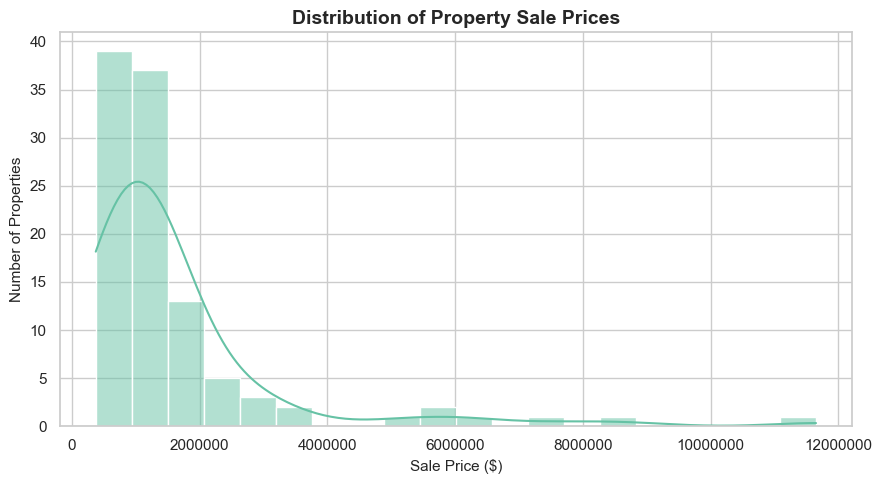

In [42]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x='SalePrice',
    bins=20,
    kde=True
)

plt.title('Distribution of Property Sale Prices')
plt.xlabel('Sale Price ($)')
plt.ylabel('Number of Properties')
plt.ticklabel_format(style='plain', axis='x')

plt.tight_layout()
plt.show()

In [43]:
df['SalePrice'].describe()

count    1.060000e+02
mean     1.612618e+06
std      1.729251e+06
min      3.750000e+05
25%      7.910000e+05
50%      1.077500e+06
75%      1.593875e+06
max      1.165000e+07
Name: SalePrice, dtype: float64

### Interpretation

The sale-price distribution is strongly right-skewed. Most properties sold below approximately $2 million, while several high-value properties, primarily in Mosman, extend the distribution substantially.

The mean sale price is higher than the median, showing that expensive properties pull the average upward. The maximum sale price of $11.65 million indicates the presence of luxury properties that may strongly influence regression performance.

In [45]:
suburb_stats = df.groupby('Suburb')['SalePrice'].agg([
    'count',
    'mean',
    'median',
    'min',
    'max'
]).round(0)

suburb_stats

,count,mean,median,min,max
Suburb,,,,,
Blacktown,35,865886.0,880000.0,375000.0,1600000.0
Marrickville,35,1363243.0,1170000.0,530000.0,3500000.0
Mosman,36,2581056.0,1445000.0,700000.0,11650000.0


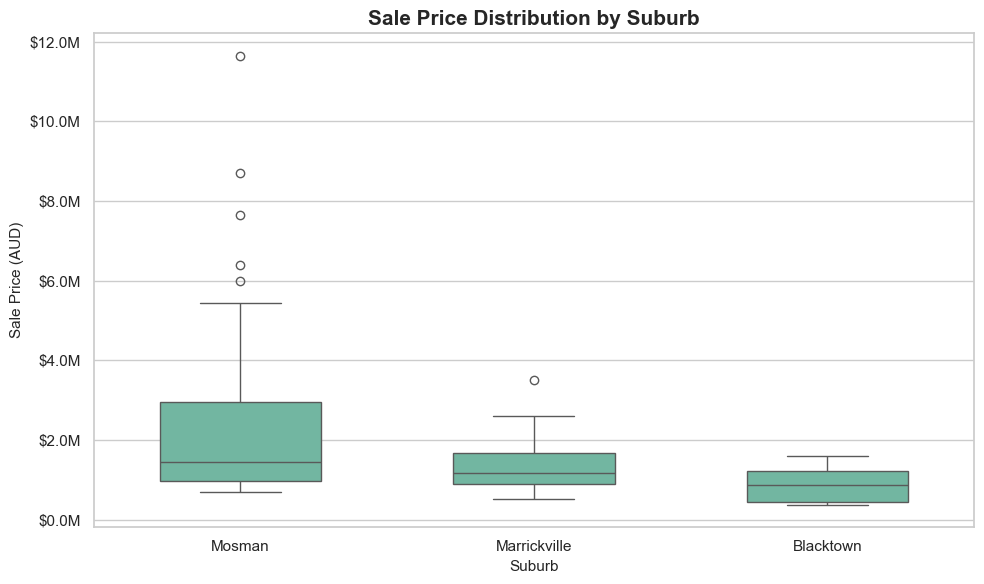

In [46]:
plt.figure(figsize=(10, 6))

order = ['Mosman', 'Marrickville', 'Blacktown']

ax = sns.boxplot(
    data=df,
    x='Suburb',
    y='SalePrice',
    order=order,
    width=0.55
)

ax.yaxis.set_major_formatter(price_formatter)

plt.title(
    'Sale Price Distribution by Suburb',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Suburb')
plt.ylabel('Sale Price (AUD)')

plt.tight_layout()
plt.show()

### Interpretation

Clear differences are visible between the three suburbs. Blacktown has the lowest typical sale prices, followed by Marrickville, while Mosman contains substantially higher-priced properties.

Mosman also shows the greatest price variation because several luxury properties sold for between approximately \\$5 million and \\$11.65 million. These differences indicate that **suburb is likely to be an important predictor of sale price**.

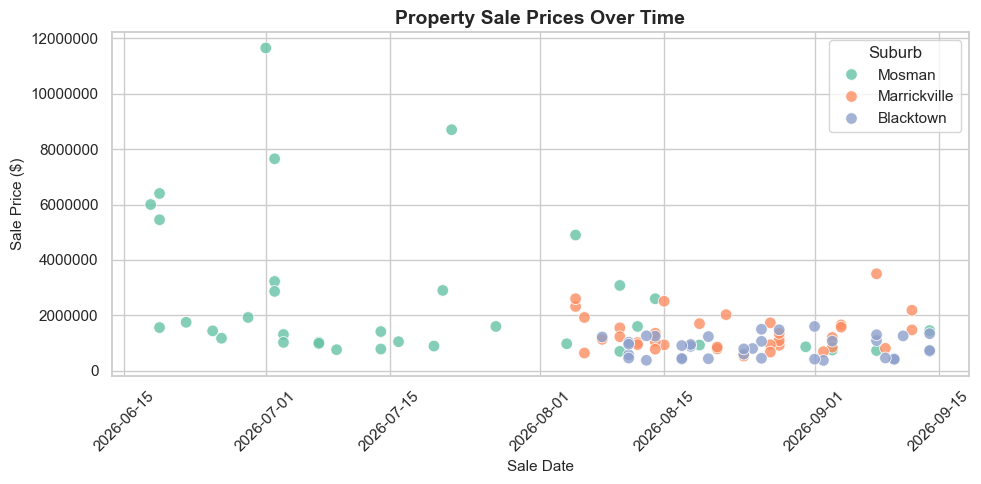

In [48]:
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=df,
    x='SaleDate',
    y='SalePrice',
    hue='Suburb',
    s=70,
    alpha=0.8
)

plt.title('Property Sale Prices Over Time')
plt.xlabel('Sale Date')
plt.ylabel('Sale Price ($)')
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Interpretation

No strong increasing or decreasing price trend is visible during the observed period. Differences between suburbs are much more noticeable than changes over time.

Because the dataset covers only a relatively short period in 2026, the results should not be interpreted as evidence of long-term housing-market trends.

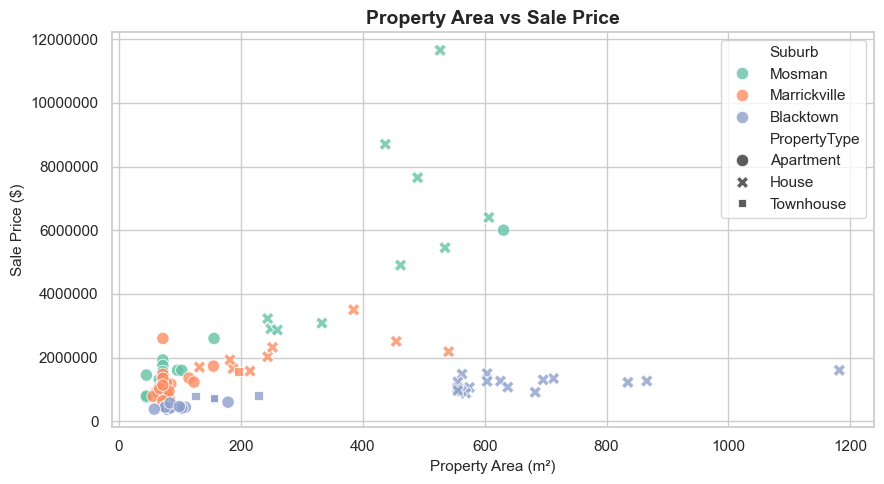

In [50]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x='Area_m2',
    y='SalePrice',
    hue='Suburb',
    style='PropertyType',
    s=80,
    alpha=0.8
)

plt.title('Property Area vs Sale Price')
plt.xlabel('Property Area (m²)')
plt.ylabel('Sale Price ($)')
plt.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

### Interpretation

Property area shows a positive relationship with sale price, although the pattern differs considerably between suburbs.

Large Blacktown properties may still sell for less than smaller Mosman properties, showing that location strongly affects property value. Area should therefore be considered together with suburb and property type rather than as an isolated predictor.

In [52]:
numeric_features = [
    'SalePrice',
    'Bedrooms',
    'Bathrooms',
    'ParkingSpaces',
    'Area_m2'
]

correlation_matrix = df[
    numeric_features
].corr()

correlation_matrix.round(2)

,SalePrice,Bedrooms,Bathrooms,ParkingSpaces,Area_m2
SalePrice,1.00,0.54,0.66,0.23,0.36
Bedrooms,0.54,1.00,0.68,0.65,0.76
Bathrooms,0.66,0.68,1.00,0.52,0.35
ParkingSpaces,0.23,0.65,0.52,1.00,0.49
Area_m2,0.36,0.76,0.35,0.49,1.00


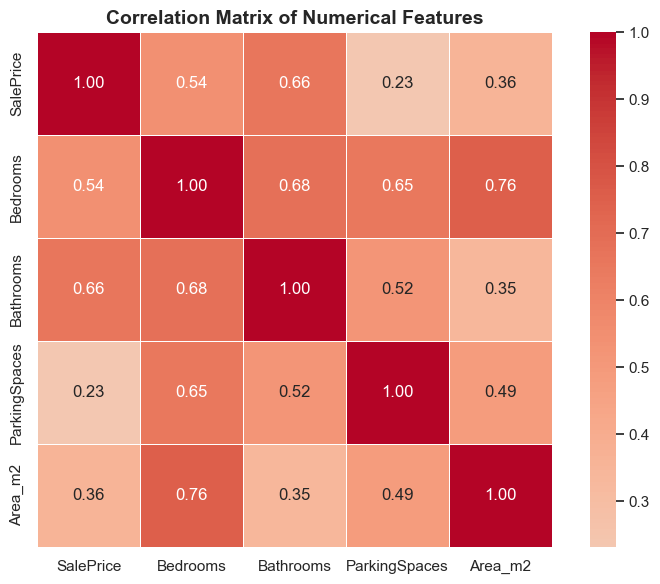

In [53]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)

plt.title('Correlation Matrix of Numerical Features')

plt.tight_layout()
plt.show()

### Interpretation

Bathrooms show the strongest positive correlation with sale price at approximately **0.66**, followed by bedrooms at **0.54**. Property area has a weaker positive relationship of approximately **0.36**, while parking spaces show the weakest correlation.

Bedrooms and property area are also relatively strongly correlated at approximately **0.76**, indicating that larger properties generally contain more bedrooms.

## 2.7 Outlier Analysis

Potential sale-price outliers are investigated using the interquartile range (IQR) method. Outliers are examined rather than automatically removed because high property prices may represent legitimate luxury properties rather than data-entry errors.

In [56]:
Q1 = df['SalePrice'].quantile(0.25)
Q3 = df['SalePrice'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Q1: 791000.0
Q3: 1593875.0
IQR: 802875.0
Lower bound: -413312.5
Upper bound: 2798187.5


### Interpretation

The IQR method identified several high-price observations as potential outliers. Most are located in Mosman and represent genuine luxury properties rather than obvious data-entry errors.

These observations were retained because removing them would exclude an important segment of the Mosman housing market. Their influence on regression performance is considered during model development.

In [58]:
price_outliers = df[
    (df['SalePrice'] < lower_bound) |
    (df['SalePrice'] > upper_bound)
].sort_values(
    'SalePrice',
    ascending=False
)

price_outliers[
    [
        'Address',
        'Suburb',
        'PropertyType',
        'Bedrooms',
        'Bathrooms',
        'Area_m2',
        'SalePrice'
    ]
]

,Address,Suburb,PropertyType,Bedrooms,Bathrooms,Area_m2,SalePrice
28,"21 Morella Road, Mosman",Mosman,House,4,4,527.0,11650000.0
12,"5 Botanic Road, Mosman NSW 2088",Mosman,House,4,3,437.0,8700000.0
25,"3 Gordon Street, Mosman",Mosman,House,5,2,490.0,7650000.0
34,"5 Central Avenue, Mosman NSW 2088",Mosman,House,5,4,607.0,6399000.0
15,"2/63 Muston Street, Mosman NSW 2088",Mosman,Apartment,4,3,631.0,6000000.0
33,"17 Avenue Road, Mosman NSW 2088",Mosman,House,5,3,535.0,5450000.0
11,"77 Belmont Road, Mosman NSW 2088",Mosman,House,4,3,462.0,4900000.0
39,"124 Warren Road, Marrickville NSW 2204",Marrickville,House,5,3,385.0,3500000.0
26,"67 Cowles Road, Mosman",Mosman,House,4,2,244.0,3225000.0
10,"22A Upper Avenue, Mosman NSW 2088",Mosman,House,4,3,333.0,3080000.0


## Expected Key Predictors of Sale Price

Based on the exploratory analysis, the following variables are expected to have a strong influence on property sale price:

1. **Suburb** – substantial price differences exist between Mosman, Marrickville and Blacktown.

2. **Property Type** – houses, apartments and townhouses represent different housing markets and price ranges.

3. **Bathrooms** – among the numerical predictors, bathrooms showed the strongest correlation with SalePrice.

These expectations will later be compared with the feature-importance results from the selected predictive model.

# Part 3: Feature Engineering

This section creates additional variables from the cleaned dataset and prepares the final set of predictors for regression modelling. Feature engineering is used to represent sale timing and reduce the effect of the strongly skewed sale-price distribution.

In [61]:
df['SaleMonth'] = df['SaleDate'].dt.month

df[['SaleDate', 'SaleMonth']].head()

,SaleDate,SaleMonth
0,2026-09-08,9
1,2026-09-03,9
2,2026-09-14,9
3,2026-08-21,8
4,2026-08-19,8


`SaleMonth` was extracted from `SaleDate` so that the models can capture any short-term differences in sale timing. Since all observations were collected within 2026, additional year-based features were not required.

In [63]:
df['TotalRooms'] = (
    df['Bedrooms'] +
    df['Bathrooms']
)

df[
    ['Bedrooms', 'Bathrooms', 'TotalRooms']
].head()

,Bedrooms,Bathrooms,TotalRooms
0,1,1,2
1,1,1,2
2,1,1,2
3,1,1,2
4,1,1,2


`TotalRooms` was created as a simple combined indicator of property size. However, because it is directly calculated from `Bedrooms` and `Bathrooms`, it is used only for exploration and is not included in the final regression predictor set to avoid redundant information.

In [65]:
df['LogSalePrice'] = np.log1p(
    df['SalePrice']
)

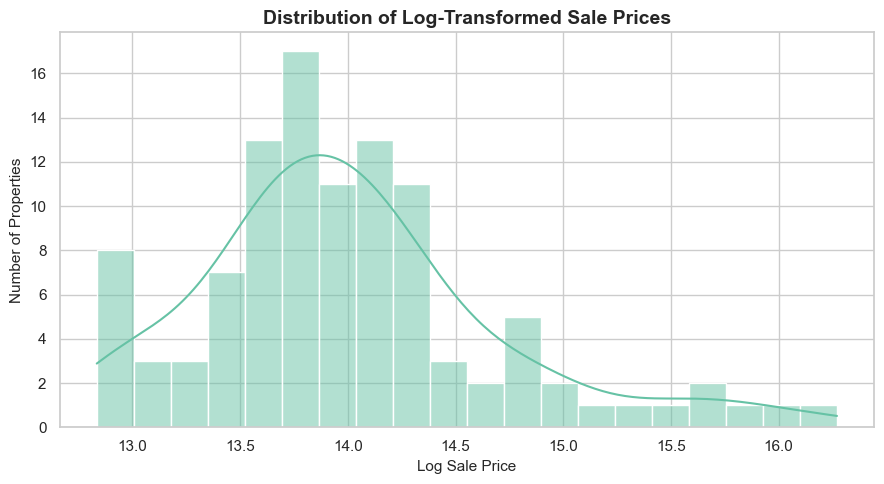

In [66]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x='LogSalePrice',
    bins=20,
    kde=True
)

plt.title('Distribution of Log-Transformed Sale Prices')
plt.xlabel('Log Sale Price')
plt.ylabel('Number of Properties')

plt.tight_layout()
plt.show()

### Interpretation

The original `SalePrice` distribution was strongly right-skewed because of several legitimate high-value properties. A logarithmic transformation was therefore created to reduce the influence of extreme values and produce a more balanced target distribution.

The original `SalePrice` variable is still retained so that final prediction errors and predicted values can be interpreted in Australian dollars.

In [68]:
features = [
    'Suburb',
    'PropertyType',
    'Bedrooms',
    'Bathrooms',
    'ParkingSpaces',
    'Area_m2',
    'SaleMonth'
]

X = df[features]
y = df['SalePrice']

print("Predictor shape:", X.shape)
print("Target shape:", y.shape)

Predictor shape: (106, 7)
Target shape: (106,)


The final predictor set contains both categorical and numerical variables.

**Categorical predictors**

- `Suburb`

- `PropertyType`

**Numerical predictors**

- `Bedrooms`

- `Bathrooms`

- `ParkingSpaces`

- `Area_m2`

- `SaleMonth`

`TotalRooms` was excluded from the final model because it is derived directly from bedrooms and bathrooms and would introduce redundant information.

In [70]:
property_type_stats = (
    df.groupby('PropertyType')['SalePrice']
    .agg([
        'count',
        'mean',
        'median',
        'min',
        'max'
    ])
    .round(0)
)

property_type_stats

,count,mean,median,min,max
PropertyType,,,,,
Apartment,64,1074141.0,932500.0,375000.0,6000000.0
House,37,2638243.0,1600000.0,880000.0,11650000.0
Townhouse,5,915500.0,790000.0,700000.0,1550000.0


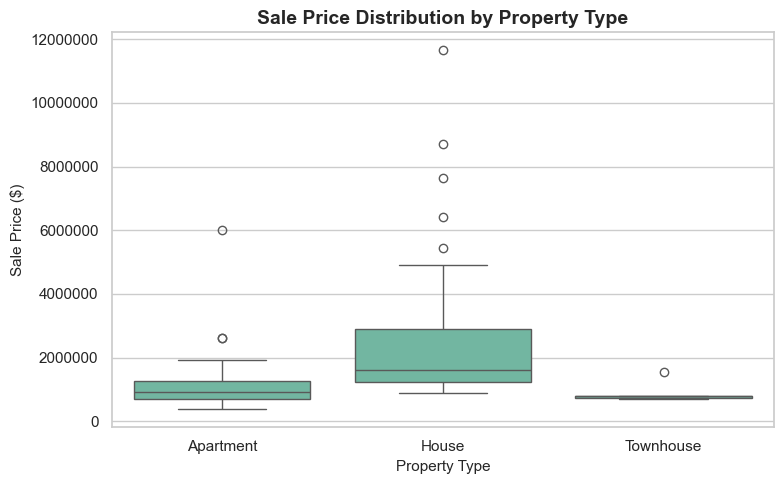

In [71]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='PropertyType',
    y='SalePrice'
)

plt.title('Sale Price Distribution by Property Type')
plt.xlabel('Property Type')
plt.ylabel('Sale Price ($)')
plt.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

### Interpretation

Property type shows noticeable differences in sale price. Houses generally have the highest median prices and the greatest variation, while apartments are typically less expensive.

Townhouses have a smaller sample size, so their price distribution should be interpreted cautiously. Overall, the differences support the inclusion of `PropertyType` as a categorical predictor in the regression models.

# Part 4: Multiple Linear Regression

This section develops a multiple linear regression model to predict property sale prices using both numerical and categorical predictors. The data is divided into training and testing sets, categorical variables are encoded, model performance is evaluated using MAE, RMSE and R², and residuals are examined to assess model assumptions.

In [74]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=df['Suburb']
)

print("Training observations:", X_train.shape[0])
print("Testing observations:", X_test.shape[0])

Training observations: 84
Testing observations: 22


A stratified 80/20 train-test split was used so that the three suburbs remained represented in both the training and testing datasets. A fixed random state was used to make the results reproducible.

In [76]:
categorical_features = [
    'Suburb',
    'PropertyType'
]

numerical_features = [
    'Bedrooms',
    'Bathrooms',
    'ParkingSpaces',
    'Area_m2',
    'SaleMonth'
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(
                drop='first',
                handle_unknown='ignore'
            ),
            categorical_features
        ),
        (
            'numerical',
            'passthrough',
            numerical_features
        )
    ]
)

Categorical variables were converted using one-hot encoding so they could be used by the regression model. One category from each categorical feature was dropped to avoid redundant dummy variables. Numerical predictors were passed through without transformation.

In [78]:
linear_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

print("Multiple Linear Regression model fitted successfully.")

Multiple Linear Regression model fitted successfully.


In [79]:
y_train_pred = linear_model.predict(X_train)
y_test_pred = linear_model.predict(X_test)

In [80]:
train_mae = mean_absolute_error(
    y_train,
    y_train_pred
)

train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        y_train_pred
    )
)

train_r2 = r2_score(
    y_train,
    y_train_pred
)

test_mae = mean_absolute_error(
    y_test,
    y_test_pred
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred
    )
)

test_r2 = r2_score(
    y_test,
    y_test_pred
)

print("TRAINING PERFORMANCE")
print(f"MAE:  ${train_mae:,.2f}")
print(f"RMSE: ${train_rmse:,.2f}")
print(f"R²:   {train_r2:.3f}")

print("\nTESTING PERFORMANCE")
print(f"MAE:  ${test_mae:,.2f}")
print(f"RMSE: ${test_rmse:,.2f}")
print(f"R²:   {test_r2:.3f}")

TRAINING PERFORMANCE
MAE:  $593,969.70
RMSE: $950,001.84
R²:   0.670

TESTING PERFORMANCE
MAE:  $670,672.91
RMSE: $1,111,802.87
R²:   0.654


### Interpretation

The multiple linear regression model explained approximately **65.4% of the variation** in sale prices within the test data.

However, the relatively high MAE and RMSE indicate that some predictions contained substantial errors. Inspection of individual predictions showed that the largest errors occurred for very expensive Mosman properties, suggesting that the standard linear model had difficulty representing the luxury segment of the market.

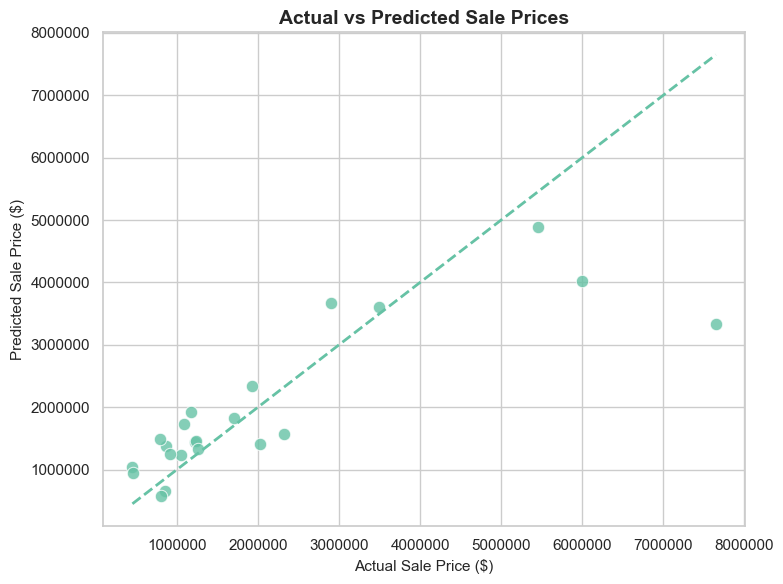

In [82]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=y_test_pred,
    s=80,
    alpha=0.8
)

min_price = min(y_test.min(), y_test_pred.min())
max_price = max(y_test.max(), y_test_pred.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    '--',
    linewidth=2
)

plt.title('Actual vs Predicted Sale Prices')
plt.xlabel('Actual Sale Price ($)')
plt.ylabel('Predicted Sale Price ($)')
plt.ticklabel_format(style='plain', axis='both')

plt.tight_layout()
plt.show()

Points close to the diagonal reference line represent accurate predictions. Most lower- and mid-priced properties are reasonably close to the line, while several high-value properties are substantially underestimated.

In [84]:
residuals = y_test - y_test_pred

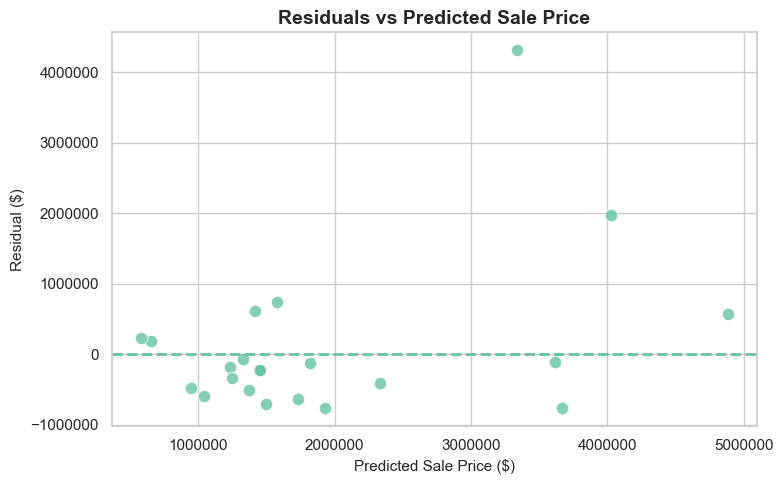

In [85]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=y_test_pred,
    y=residuals,
    s=80,
    alpha=0.8
)

plt.axhline(
    0,
    linestyle='--',
    linewidth=2
)

plt.title('Residuals vs Predicted Sale Price')
plt.xlabel('Predicted Sale Price ($)')
plt.ylabel('Residual ($)')
plt.ticklabel_format(style='plain', axis='both')

plt.tight_layout()
plt.show()

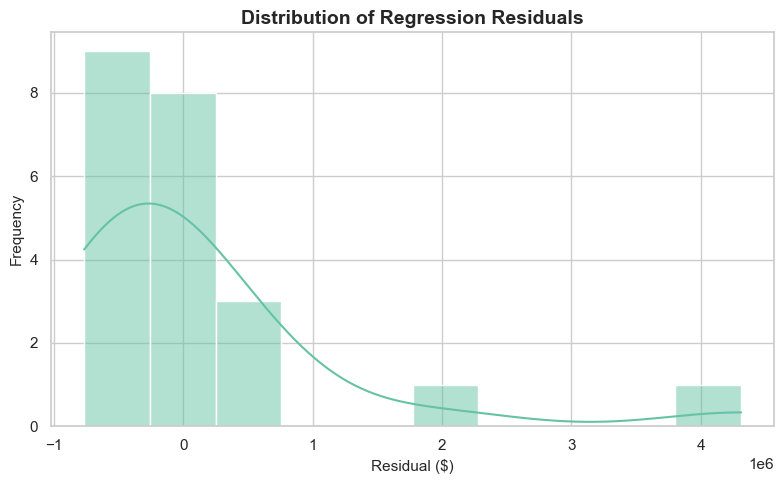

In [86]:
plt.figure(figsize=(8, 5))

sns.histplot(
    residuals,
    bins=10,
    kde=True
)

plt.title('Distribution of Regression Residuals')
plt.xlabel('Residual ($)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Residual Interpretation

The residuals are not evenly distributed around zero. Larger residuals occur for high-value properties, indicating that prediction errors increase as property prices rise.

The residual histogram is also positively skewed. This suggests that the assumptions of constant residual variance and approximately normal residuals are not fully satisfied.

In [88]:
prediction_results = X_test.copy()

prediction_results['ActualPrice'] = y_test
prediction_results['PredictedPrice'] = y_test_pred

prediction_results['AbsoluteError'] = abs(
    prediction_results['ActualPrice']
    - prediction_results['PredictedPrice']
)

prediction_results = (
    prediction_results
    .sort_values(
        'AbsoluteError',
        ascending=False
    )
)

prediction_results[
    [
        'Suburb',
        'PropertyType',
        'Bedrooms',
        'Bathrooms',
        'Area_m2',
        'ActualPrice',
        'PredictedPrice',
        'AbsoluteError'
    ]
].head(10)

,Suburb,PropertyType,Bedrooms,Bathrooms,Area_m2,ActualPrice,PredictedPrice,AbsoluteError
25,Mosman,House,5,2,490.0,7650000.0,3.336391e+06,4.313609e+06
15,Mosman,Apartment,4,3,631.0,6000000.0,4.026669e+06,1.973331e+06
13,Mosman,House,3,2,249.0,2900000.0,3.666662e+06,7.666623e+05
42,Marrickville,Apartment,2,2,85.0,1170000.0,1.928403e+06,7.584032e+05
69,Marrickville,House,3,1,252.0,2320000.0,1.578256e+06,7.417440e+05
3,Mosman,Apartment,1,1,45.0,790000.0,1.495088e+06,7.050877e+05
78,Blacktown,House,5,2,556.0,1089000.0,1.730142e+06,6.411418e+05
53,Marrickville,House,3,1,244.0,2025000.0,1.412958e+06,6.120425e+05
85,Blacktown,Apartment,2,2,75.0,452000.0,1.042936e+06,5.909360e+05
33,Mosman,House,5,3,535.0,5450000.0,4.881351e+06,5.686494e+05


The largest prediction errors mainly involve high-value Mosman properties. For example, one property that sold for approximately $7.65 million was predicted at only around $3.34 million. This confirms that the original linear model systematically underestimates some luxury properties.

### Linear Regression Assumptions

**Linearity:**  
The model assumes approximately linear relationships between predictors and sale price. The large errors observed for high-value properties suggest that this assumption is only partly satisfied.

**Independence:**  
Each observation represents a separate property transaction and is treated as independent.

**Homoscedasticity:**  
Residual spread increases for higher-priced properties, suggesting that constant variance is not fully satisfied.

**Normality of residuals:**  
The residual distribution is positively skewed due to several large prediction errors.

**Multicollinearity:**  
Some predictors contain related information. For example, bedrooms and property area showed a relatively strong correlation. This should be considered when interpreting individual predictor effects.

## Log-Target Linear Regression

Because the original sale-price distribution was strongly right-skewed, a second linear regression model was trained using `LogSalePrice` as the target. Predictions were transformed back into Australian dollars for direct comparison with the original model.

In [92]:
y_log_train = np.log1p(y_train)
y_log_test = np.log1p(y_test)

log_linear_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ]
)

log_linear_model.fit(
    X_train,
    y_log_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['Suburb','PropertyType','Bedrooms',...,'ParkingSpaces','Area_m2', 'SaleMonth']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through

In [93]:
log_train_pred = log_linear_model.predict(
    X_train
)

log_test_pred = log_linear_model.predict(
    X_test
)

y_train_pred_log_model = np.expm1(
    log_train_pred
)

y_test_pred_log_model = np.expm1(
    log_test_pred
)

In [94]:
log_train_mae = mean_absolute_error(
    y_train,
    y_train_pred_log_model
)

log_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        y_train_pred_log_model
    )
)

log_train_r2 = r2_score(
    y_train,
    y_train_pred_log_model
)

log_test_mae = mean_absolute_error(
    y_test,
    y_test_pred_log_model
)

log_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred_log_model
    )
)

log_test_r2 = r2_score(
    y_test,
    y_test_pred_log_model
)

print("LOG-TARGET LINEAR REGRESSION")

print("\nTRAINING PERFORMANCE")
print(f"MAE:  ${log_train_mae:,.2f}")
print(f"RMSE: ${log_train_rmse:,.2f}")
print(f"R²:   {log_train_r2:.3f}")

print("\nTESTING PERFORMANCE")
print(f"MAE:  ${log_test_mae:,.2f}")
print(f"RMSE: ${log_test_rmse:,.2f}")
print(f"R²:   {log_test_r2:.3f}")

LOG-TARGET LINEAR REGRESSION

TRAINING PERFORMANCE
MAE:  $345,875.55
RMSE: $836,641.16
R²:   0.744

TESTING PERFORMANCE
MAE:  $417,309.94
RMSE: $907,004.19
R²:   0.770


### Interpretation: Log-Target Model

The log-target model substantially improved predictive performance. Test MAE decreased from approximately **\\$670,673 to \\$417,310**, while RMSE decreased from approximately **\\$1.11 million to \\$907,004**.

Test R² increased from **0.654 to 0.770**, meaning that the log-target model explained approximately 77% of the variation in unseen property prices.

The improvement indicates that reducing the influence of extreme luxury-property prices helped the linear model generalise more effectively.

# Part 5: Polynomial Regression

This section develops a second-degree polynomial regression model to investigate whether nonlinear relationships between property characteristics and sale price can improve predictive performance. The polynomial model is evaluated on the same training and testing data used for the linear models so that results can be compared fairly.

In [97]:
polynomial_numeric_pipeline = Pipeline(
    steps=[
        (
            'polynomial',
            PolynomialFeatures(
                degree=2,
                include_bias=False
            )
        ),
        (
            'scaler',
            StandardScaler()
        )
    ]
)

In [98]:
polynomial_preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(
                drop='first',
                handle_unknown='ignore'
            ),
            categorical_features
        ),
        (
            'polynomial_numerical',
            polynomial_numeric_pipeline,
            numerical_features
        )
    ]
)

Second-degree polynomial features were created for the numerical predictors to allow the model to capture nonlinear relationships and interactions between property characteristics. Numerical polynomial terms were standardised, while categorical variables continued to use one-hot encoding.

In [100]:
polynomial_model = Pipeline(
    steps=[
        ('preprocessor', polynomial_preprocessor),
        ('regressor', LinearRegression())
    ]
)

polynomial_model.fit(
    X_train,
    y_train
)

print("Polynomial Regression model fitted successfully.")

Polynomial Regression model fitted successfully.


In [101]:
poly_train_pred = polynomial_model.predict(
    X_train
)

poly_test_pred = polynomial_model.predict(
    X_test
)

In [102]:
poly_train_mae = mean_absolute_error(
    y_train,
    poly_train_pred
)

poly_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        poly_train_pred
    )
)

poly_train_r2 = r2_score(
    y_train,
    poly_train_pred
)

poly_test_mae = mean_absolute_error(
    y_test,
    poly_test_pred
)

poly_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        poly_test_pred
    )
)

poly_test_r2 = r2_score(
    y_test,
    poly_test_pred
)

print("POLYNOMIAL REGRESSION")

print("\nTRAINING PERFORMANCE")
print(f"MAE:  ${poly_train_mae:,.2f}")
print(f"RMSE: ${poly_train_rmse:,.2f}")
print(f"R²:   {poly_train_r2:.3f}")

print("\nTESTING PERFORMANCE")
print(f"MAE:  ${poly_test_mae:,.2f}")
print(f"RMSE: ${poly_test_rmse:,.2f}")
print(f"R²:   {poly_test_r2:.3f}")

POLYNOMIAL REGRESSION

TRAINING PERFORMANCE
MAE:  $344,205.65
RMSE: $540,796.81
R²:   0.893

TESTING PERFORMANCE
MAE:  $843,627.71
RMSE: $1,307,345.93
R²:   0.521


### Interpretation

The polynomial regression model fitted the training data very strongly, with a training R² of approximately **0.893**. However, its test R² fell to approximately **0.521**, and both MAE and RMSE were higher than those of the linear models.

This large difference between training and testing performance suggests that the polynomial model overfits the training data. Increasing model complexity therefore did not improve generalisation to unseen properties.

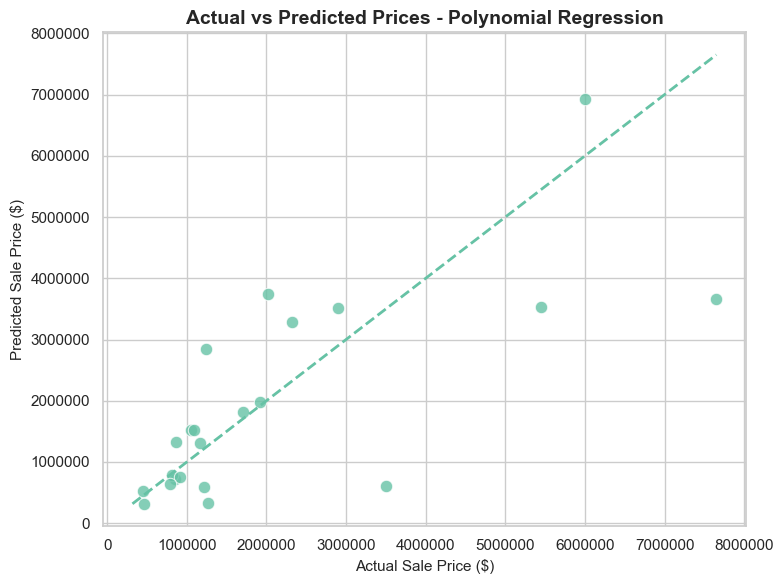

In [104]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=poly_test_pred,
    s=80,
    alpha=0.8
)

min_price = min(
    y_test.min(),
    poly_test_pred.min()
)

max_price = max(
    y_test.max(),
    poly_test_pred.max()
)

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle='--',
    linewidth=2
)

plt.title(
    'Actual vs Predicted Prices - Polynomial Regression'
)

plt.xlabel('Actual Sale Price ($)')
plt.ylabel('Predicted Sale Price ($)')

plt.ticklabel_format(
    style='plain',
    axis='both'
)

plt.tight_layout()
plt.show()

The Actual vs Predicted plot shows substantial deviation from the ideal diagonal line for several properties, particularly at higher price levels. This indicates that the polynomial model produces less reliable predictions on unseen data.

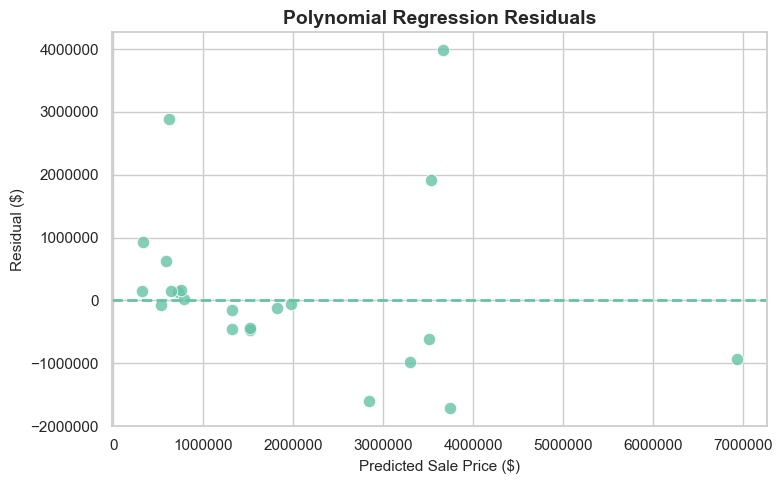

In [106]:
poly_residuals = y_test - poly_test_pred

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=poly_test_pred,
    y=poly_residuals,
    s=80,
    alpha=0.8
)

plt.axhline(
    y=0,
    linestyle='--',
    linewidth=2
)

plt.title('Polynomial Regression Residuals')

plt.xlabel('Predicted Sale Price ($)')
plt.ylabel('Residual ($)')

plt.ticklabel_format(
    style='plain',
    axis='both'
)

plt.tight_layout()
plt.show()

The residual plot shows large positive and negative errors, indicating that the polynomial model does not generalise consistently across the full price range.

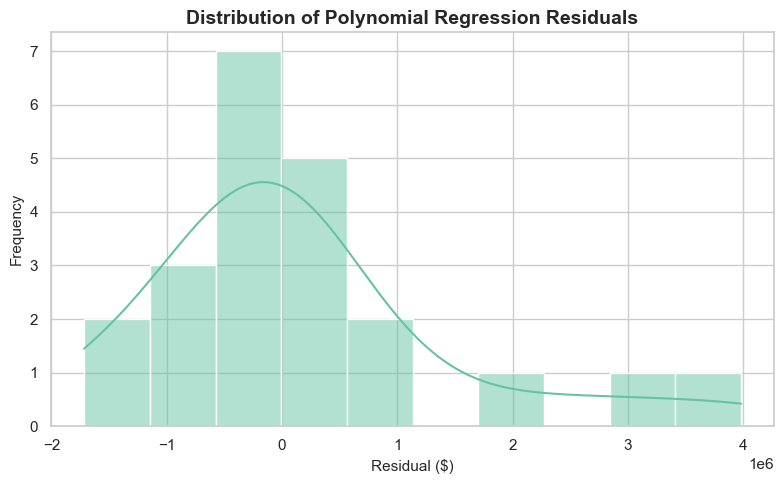

In [108]:
plt.figure(figsize=(8, 5))

sns.histplot(
    poly_residuals,
    bins=10,
    kde=True
)

plt.title(
    'Distribution of Polynomial Regression Residuals'
)

plt.xlabel('Residual ($)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [109]:
model_comparison = pd.DataFrame({
    'Model': [
        'Multiple Linear Regression',
        'Log-Target Linear Regression',
        'Polynomial Regression'
    ],

    'Test MAE': [
        test_mae,
        log_test_mae,
        poly_test_mae
    ],

    'Test RMSE': [
        test_rmse,
        log_test_rmse,
        poly_test_rmse
    ],

    'Test R2': [
        test_r2,
        log_test_r2,
        poly_test_r2
    ]
})

model_comparison.round(3)

,Model,Test MAE,Test RMSE,Test R2
0,Multiple Linear Regression,670672.909,1111802.867,0.654
1,Log-Target Linear Regression,417309.944,907004.186,0.770
2,Polynomial Regression,843627.711,1307345.926,0.521


In [110]:
training_comparison = pd.DataFrame({
    'Model': [
        'Multiple Linear Regression',
        'Log-Target Linear Regression',
        'Polynomial Regression'
    ],

    'Train R2': [
        train_r2,
        log_train_r2,
        poly_train_r2
    ],

    'Test R2': [
        test_r2,
        log_test_r2,
        poly_test_r2
    ]
})

training_comparison['R2 Gap'] = (
    training_comparison['Train R2'] -
    training_comparison['Test R2']
)

training_comparison.round(3)

,Model,Train R2,Test R2,R2 Gap
0,Multiple Linear Regression,0.670,0.654,0.016
1,Log-Target Linear Regression,0.744,0.770,-0.026
2,Polynomial Regression,0.893,0.521,0.372


### Model Complexity and Generalisation

The polynomial model achieved the highest training R² but the lowest testing R², producing the largest gap between training and testing performance. This indicates clear overfitting.

By comparison, the log-target linear regression showed similar training and testing performance and achieved the strongest results on unseen data. Therefore, increasing model complexity did not improve predictive accuracy for this dataset.

# Part 6: Model Comparison and Interpretation

This section compares the regression models using test-set performance, identifies the most influential predictors, applies the selected model to a hypothetical property, and discusses the limitations and responsible use of the predictions.

In [113]:
comparison_display = model_comparison.copy()

comparison_display['Test MAE'] = (
    comparison_display['Test MAE'].round(0)
)

comparison_display['Test RMSE'] = (
    comparison_display['Test RMSE'].round(0)
)

comparison_display['Test R2'] = (
    comparison_display['Test R2'].round(3)
)

comparison_display

,Model,Test MAE,Test RMSE,Test R2
0,Multiple Linear Regression,670673.0,1111803.0,0.654
1,Log-Target Linear Regression,417310.0,907004.0,0.770
2,Polynomial Regression,843628.0,1307346.0,0.521


### Interpretation

The **log-target linear regression** produced the strongest performance on the test dataset.

It achieved:

- **MAE:** approximately $417,310

- **RMSE:** approximately $907,004

- **R²:** 0.770

The standard multiple linear regression achieved a lower R² of 0.654, while polynomial regression performed worst with a test R² of 0.521.

The results show that transforming the strongly skewed SalePrice target improved generalisation more effectively than increasing model complexity. Therefore, the log-target linear regression was selected as the preferred model.

In [115]:
importance_result = permutation_importance(
    log_linear_model,
    X_test,
    y_log_test,
    n_repeats=30,
    random_state=42,
    scoring='r2'
)

feature_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': (
        importance_result.importances_mean
    )
}).sort_values(
    'Importance',
    ascending=False
)

feature_importance

,Feature,Importance
0,Suburb,0.772922
1,PropertyType,0.172374
2,Bedrooms,0.161709
5,Area_m2,0.124087
3,Bathrooms,0.112229
6,SaleMonth,0.017739
4,ParkingSpaces,-0.001495


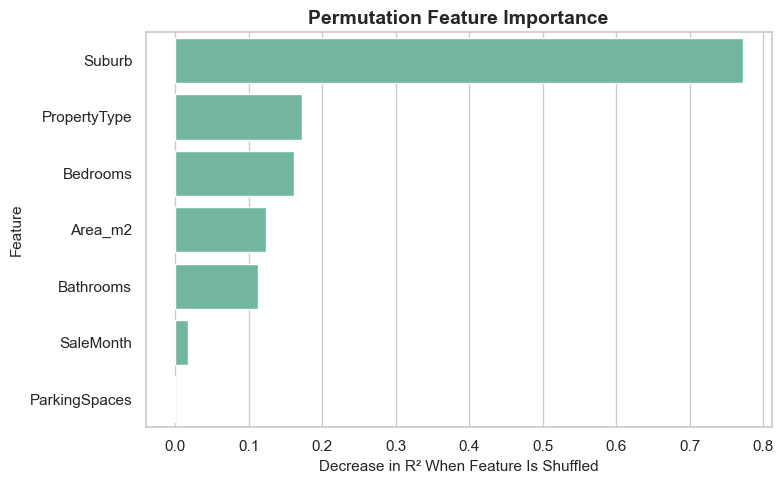

In [116]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title('Permutation Feature Importance')
plt.xlabel('Decrease in R² When Feature Is Shuffled')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

### Interpretation

Permutation importance shows that **Suburb** was by far the most influential predictor in the selected model.

`PropertyType` and `Bedrooms` were the next most influential variables, followed by `Area_m2` and `Bathrooms`.

These results partly support the expectations formed during exploratory analysis. Suburb and property type were correctly expected to have strong influence, while bedrooms became more important than bathrooms in the final model.

`SaleMonth` contributed very little predictive information, which is reasonable because the dataset covers only a short time period. `ParkingSpaces` had importance close to zero, suggesting that it added little extra predictive information after the other variables were considered.

## Investigation of the Five Largest Prediction Errors

To better understand the limitations of the selected model, the five largest prediction errors from the log-target linear regression model are examined. Absolute and percentage errors are calculated to identify the types of properties that are most difficult for the model to predict accurately.

In [119]:
log_error_results = X_test.copy()

log_error_results['ActualPrice'] = y_test
log_error_results['PredictedPrice'] = y_test_pred_log_model

log_error_results['AbsoluteError'] = abs(
    log_error_results['ActualPrice']
    - log_error_results['PredictedPrice']
)

log_error_results['PercentError'] = (
    100
    * log_error_results['AbsoluteError']
    / log_error_results['ActualPrice']
)

top5_log_errors = (
    log_error_results
    .sort_values('AbsoluteError', ascending=False)
    .head(5)
)

top5_log_errors[
    [
        'Suburb',
        'PropertyType',
        'Bedrooms',
        'Bathrooms',
        'ParkingSpaces',
        'Area_m2',
        'ActualPrice',
        'PredictedPrice',
        'AbsoluteError',
        'PercentError'
    ]
]

,Suburb,PropertyType,Bedrooms,Bathrooms,ParkingSpaces,Area_m2,ActualPrice,PredictedPrice,AbsoluteError,PercentError
25,Mosman,House,5,2,2,490.0,7650000.0,4.344344e+06,3.305656e+06,43.211186
15,Mosman,Apartment,4,3,3,631.0,6000000.0,3.496522e+06,2.503478e+06,41.724632
69,Marrickville,House,3,1,1,252.0,2320000.0,1.845232e+06,4.747683e+05,20.464151
78,Blacktown,House,5,2,2,556.0,1089000.0,1.476678e+06,3.876776e+05,35.599416
39,Marrickville,House,5,3,3,385.0,3500000.0,3.877013e+06,3.770134e+05,10.771811


### Error Analysis

The largest prediction error occurred for a Mosman house that sold for \\$7.65 million. The model predicted approximately \\$4.34 million, underestimating the property by about \\$3.31 million, or 43.2%.

A Mosman apartment that sold for \\$6 million was also substantially underestimated, with an error of approximately \\$2.50 million (41.7%). These properties are located at the upper end of the market and may contain luxury characteristics that are not represented by the available predictors.

The Blacktown five-bedroom house also produced a relatively high percentage error despite having a much lower sale price. This suggests that unusual combinations of property characteristics can also be difficult for the model to represent.

Overall, the largest errors demonstrate that the model has limited information about property condition, renovations, views, exact street location and other premium characteristics. These omitted features are particularly important for unusual and high-value properties.

## Model Export for Deployment

The selected log-target linear regression pipeline is saved so that the same preprocessing steps and trained regression model can be loaded by the Streamlit application without retraining.

In [122]:
joblib.dump(
    log_linear_model,
    'log_linear_model.pkl'
)

print("Model saved to log_linear_model.pkl")

Model saved to log_linear_model.pkl


In [123]:
hypothetical_property = pd.DataFrame({
    'Suburb': ['Marrickville'],
    'PropertyType': ['House'],
    'Bedrooms': [3],
    'Bathrooms': [2],
    'ParkingSpaces': [1],
    'Area_m2': [250],
    'SaleMonth': [9]
})

hypothetical_property

,Suburb,PropertyType,Bedrooms,Bathrooms,ParkingSpaces,Area_m2,SaleMonth
0,Marrickville,House,3,2,1,250,9


In [124]:
predicted_log_price = (
    log_linear_model.predict(
        hypothetical_property
    )
)

predicted_price = np.expm1(
    predicted_log_price
)[0]

print(
    f"Predicted sale price: "
    f"${predicted_price:,.0f}"
)

Predicted sale price: $2,219,326


### Interpretation

The selected model estimated a sale price of approximately **\\$2.22 million** for a hypothetical Marrickville house with three bedrooms, two bathrooms, one parking space and an area of 250 m².

This prediction is higher than the overall Marrickville median in the dataset, but it is reasonable for a larger house with these characteristics. Similar three-bedroom houses in the collected data sold around the \\$2 million range.

The prediction should be interpreted as an estimate rather than an exact market valuation because many property-specific factors are not included in the model.

## Model Limitations

Several limitations affect the reliability of the results.

First, the dataset contains only **106 properties across three Sydney suburbs**, so it represents only a small part of the wider property market.

Second, the observations cover a relatively short period in 2026. The models therefore cannot capture long-term changes in market conditions, interest rates or economic trends.

Third, `Area_m2` represents land size for houses but generally represents floor or unit area for apartments. Although useful as a property-size measure, it does not have exactly the same meaning across all property types.

Some missing area values were also imputed using median values for the relevant suburb and property type.

Finally, factors such as property condition, renovations, exact street location, views, school catchments, proximity to transport and neighbourhood characteristics were not included. These omitted variables may explain some of the remaining prediction error, particularly for luxury properties.

## Responsible Use

The model should be used as a supporting analytical tool rather than as a replacement for professional property valuation.

Predictions are based only on the variables and historical sales contained in the dataset and therefore contain uncertainty. Predictions may be less reliable for unusual or luxury properties that differ substantially from the observations used for training.

In real-world use, the model should be updated regularly with newer sales data and additional property and location features. Users should also be informed that predictions are approximate estimates rather than guaranteed market values.

For this reason, the model is most appropriate for exploratory analysis and approximate price estimation rather than financial, lending or investment decisions without additional evidence.

# Part 7: Final Findings

This project investigated residential property sale prices across Mosman, Marrickville and Blacktown using exploratory analysis and several regression approaches.

The exploratory analysis showed clear differences between suburbs. Mosman contained the highest-priced properties and the greatest variation in sale prices, while Blacktown generally had the lowest prices. Property type also influenced value, with houses typically selling for more than apartments.

Three regression approaches were compared:

- Multiple Linear Regression

- Log-Target Linear Regression

- Polynomial Regression

The **log-target linear regression** achieved the strongest performance on unseen test data, with:

- **MAE:** approximately $417,310

- **RMSE:** approximately $907,004

- **R²:** 0.770

The standard linear regression achieved a test R² of 0.654, while polynomial regression performed worse with a test R² of 0.521 and showed clear signs of overfitting.

Permutation importance showed that **Suburb** was the most influential predictor, followed by **PropertyType** and **Bedrooms**. This confirms that location plays a major role in property valuation.

Overall, the results show that transforming the skewed sale-price target improved prediction performance more effectively than increasing model complexity. The selected model provides useful approximate estimates, but predictions should still be interpreted cautiously because the dataset is relatively small and does not include every factor that can influence property value.

## Key Takeaway

A simpler model with an appropriate target transformation generalised better than a more complex polynomial model. In this dataset, location and property characteristics were more important than increasing model complexity.